## Import Libraries and Dataset

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_excel('online_retail_II.xlsx', sheet_name=0)
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


## Exploratory Data Analysis (EDA)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      525461 non-null  object        
 1   StockCode    525461 non-null  object        
 2   Description  522533 non-null  object        
 3   Quantity     525461 non-null  int64         
 4   InvoiceDate  525461 non-null  datetime64[ns]
 5   Price        525461 non-null  float64       
 6   Customer ID  417534 non-null  float64       
 7   Country      525461 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 32.1+ MB


In [5]:
df.describe()

,Quantity,InvoiceDate,Price,Customer ID
count,525461.000000,525461,525461.000000,417534.000000
mean,10.337667,2010-06-28 11:37:36.845017856,4.688834,15360.645478
min,-9600.000000,2009-12-01 07:45:00,-53594.360000,12346.000000
25%,1.000000,2010-03-21 12:20:00,1.250000,13983.000000
50%,3.000000,2010-07-06 09:51:00,2.100000,15311.000000
75%,10.000000,2010-10-15 12:45:00,4.210000,16799.000000
max,19152.000000,2010-12-09 20:01:00,25111.090000,18287.000000
std,107.424110,NaN,146.126914,1680.811316


In [6]:
df.describe(include='O')

,Invoice,StockCode,Description,Country
count,525461,525461,522533,525461
unique,28816,4632,4681,40
top,537434,85123A,WHITE HANGING HEART T-LIGHT HOLDER,United Kingdom
freq,675,3516,3549,485852


In [7]:
df.isna().sum()

Invoice             0
StockCode           0
Description      2928
Quantity            0
InvoiceDate         0
Price               0
Customer ID    107927
Country             0
dtype: int64

In [8]:
df[df['Customer ID'].isna()]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
263,489464,21733,85123a mixed,-96,2009-12-01 10:52:00,0.00,NaN,United Kingdom
283,489463,71477,short,-240,2009-12-01 10:52:00,0.00,NaN,United Kingdom
284,489467,85123A,21733 mixed,-192,2009-12-01 10:53:00,0.00,NaN,United Kingdom
470,489521,21646,NaN,-50,2009-12-01 11:44:00,0.00,NaN,United Kingdom
577,489525,85226C,BLUE PULL BACK RACING CAR,1,2009-12-01 11:49:00,0.55,NaN,United Kingdom
...,...,...,...,...,...,...,...,...
525231,538159,21324,NaN,-18,2010-12-09 17:17:00,0.00,NaN,United Kingdom
525232,538158,20892,NaN,-32,2010-12-09 17:17:00,0.00,NaN,United Kingdom
525233,538160,20956,NaN,288,2010-12-09 17:18:00,0.00,NaN,United Kingdom
525234,538161,46000S,Dotcom sales,-100,2010-12-09 17:25:00,0.00,NaN,United Kingdom


In [9]:
df[df['Quantity']<0]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.0,Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.0,Australia
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.0,Australia
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
...,...,...,...,...,...,...,...,...
525231,538159,21324,NaN,-18,2010-12-09 17:17:00,0.00,NaN,United Kingdom
525232,538158,20892,NaN,-32,2010-12-09 17:17:00,0.00,NaN,United Kingdom
525234,538161,46000S,Dotcom sales,-100,2010-12-09 17:25:00,0.00,NaN,United Kingdom
525235,538162,46000M,Dotcom sales,-100,2010-12-09 17:25:00,0.00,NaN,United Kingdom


In [10]:
df['Invoice'] = df['Invoice'].astype('str')
df[df['Invoice'].str.match('^\\d{6}$')==True]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
...,...,...,...,...,...,...,...,...
525456,538171,22271,FELTCRAFT DOLL ROSIE,2,2010-12-09 20:01:00,2.95,17530.0,United Kingdom
525457,538171,22750,FELTCRAFT PRINCESS LOLA DOLL,1,2010-12-09 20:01:00,3.75,17530.0,United Kingdom
525458,538171,22751,FELTCRAFT PRINCESS OLIVIA DOLL,1,2010-12-09 20:01:00,3.75,17530.0,United Kingdom
525459,538171,20970,PINK FLORAL FELTCRAFT SHOULDER BAG,2,2010-12-09 20:01:00,3.75,17530.0,United Kingdom


In [11]:
df['Invoice'].str.replace('[0-9]', '', regex=True).unique()

array(['', 'C', 'A'], dtype=object)

In [12]:
df[df['Invoice'].str.startswith('A')]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
179403,A506401,B,Adjust bad debt,1,2010-04-29 13:36:00,-53594.36,NaN,United Kingdom
276274,A516228,B,Adjust bad debt,1,2010-07-19 11:24:00,-44031.79,NaN,United Kingdom
403472,A528059,B,Adjust bad debt,1,2010-10-20 12:04:00,-38925.87,NaN,United Kingdom


In [13]:
df['StockCode'] = df['StockCode'].astype('str')
df[(df['StockCode'].str.match('^\\d{5}$') == False) & (df['StockCode'].str.match('^\\d{5}[a-zA-Z]+$')==False)]['StockCode'].unique() # '+' sign for repetition of letters

array(['POST', 'D', 'DCGS0058', 'DCGS0068', 'DOT', 'M', 'DCGS0004',
       'DCGS0076', 'C2', 'BANK CHARGES', 'DCGS0003', 'TEST001',
       'gift_0001_80', 'DCGS0072', 'gift_0001_20', 'DCGS0044', 'TEST002',
       'gift_0001_10', 'gift_0001_50', 'DCGS0066N', 'gift_0001_30',
       'PADS', 'ADJUST', 'gift_0001_40', 'gift_0001_60', 'gift_0001_70',
       'gift_0001_90', 'DCGSSGIRL', 'DCGS0006', 'DCGS0016', 'DCGS0027',
       'DCGS0036', 'DCGS0039', 'DCGS0060', 'DCGS0056', 'DCGS0059', 'GIFT',
       'DCGSLBOY', 'm', 'DCGS0053', 'DCGS0062', 'DCGS0037', 'DCGSSBOY',
       'DCGSLGIRL', 'S', 'DCGS0069', 'DCGS0070', 'DCGS0075', 'B',
       'DCGS0041', 'ADJUST2', '47503J ', 'C3', 'SP1002', 'AMAZONFEE'],
      dtype=object)

In [14]:
df[df['StockCode'].str.contains('^DOT')]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
2379,489597,DOT,DOTCOM POSTAGE,1,2009-12-01 14:28:00,647.19,NaN,United Kingdom
2539,489600,DOT,DOTCOM POSTAGE,1,2009-12-01 14:43:00,55.96,NaN,United Kingdom
2551,489601,DOT,DOTCOM POSTAGE,1,2009-12-01 14:44:00,68.39,NaN,United Kingdom
2571,489602,DOT,DOTCOM POSTAGE,1,2009-12-01 14:45:00,59.35,NaN,United Kingdom
2619,489603,DOT,DOTCOM POSTAGE,1,2009-12-01 14:46:00,42.39,NaN,United Kingdom
...,...,...,...,...,...,...,...,...
524272,538071,DOT,DOTCOM POSTAGE,1,2010-12-09 14:09:00,885.94,NaN,United Kingdom
524887,538148,DOT,DOTCOM POSTAGE,1,2010-12-09 16:26:00,547.32,NaN,United Kingdom
525000,538149,DOT,DOTCOM POSTAGE,1,2010-12-09 16:27:00,620.68,NaN,United Kingdom
525126,538153,DOT,DOTCOM POSTAGE,1,2010-12-09 16:31:00,822.94,NaN,United Kingdom


## Data Cleaning


In [15]:
df_cleaned = df.copy()

In [16]:
df_cleaned['Invoice'] = df_cleaned['Invoice'].astype('str')

mask = (
    df_cleaned['Invoice'].str.match('^\\d{6}$')==True
)

df_cleaned = df_cleaned[mask]

In [17]:
df_cleaned['StockCode'] = df_cleaned['StockCode'].astype('str')
mask1  = (
    (df_cleaned['StockCode'].str.match('^\\d{5}$')== True) |
    (df_cleaned['StockCode'].str.match('^\\d{5}[a-zA-Z]+$')== True) |
    (df_cleaned['StockCode'].str.match('^PADS$')==True)
    )
df_cleaned = df_cleaned[mask]
df_cleaned

C:\Users\Mahmoud Ibrahim\AppData\Local\Temp\ipykernel_10100\1500319921.py:7: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_cleaned = df_cleaned[mask]


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
...,...,...,...,...,...,...,...,...
525456,538171,22271,FELTCRAFT DOLL ROSIE,2,2010-12-09 20:01:00,2.95,17530.0,United Kingdom
525457,538171,22750,FELTCRAFT PRINCESS LOLA DOLL,1,2010-12-09 20:01:00,3.75,17530.0,United Kingdom
525458,538171,22751,FELTCRAFT PRINCESS OLIVIA DOLL,1,2010-12-09 20:01:00,3.75,17530.0,United Kingdom
525459,538171,20970,PINK FLORAL FELTCRAFT SHOULDER BAG,2,2010-12-09 20:01:00,3.75,17530.0,United Kingdom


In [18]:
df_cleaned.dropna(subset= ['Customer ID'], inplace=True)
df_cleaned

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
...,...,...,...,...,...,...,...,...
525456,538171,22271,FELTCRAFT DOLL ROSIE,2,2010-12-09 20:01:00,2.95,17530.0,United Kingdom
525457,538171,22750,FELTCRAFT PRINCESS LOLA DOLL,1,2010-12-09 20:01:00,3.75,17530.0,United Kingdom
525458,538171,22751,FELTCRAFT PRINCESS OLIVIA DOLL,1,2010-12-09 20:01:00,3.75,17530.0,United Kingdom
525459,538171,20970,PINK FLORAL FELTCRAFT SHOULDER BAG,2,2010-12-09 20:01:00,3.75,17530.0,United Kingdom


In [19]:
df_cleaned.describe()

,Quantity,InvoiceDate,Price,Customer ID
count,407695.000000,407695,407695.000000,407695.000000
mean,13.586686,2010-07-01 10:10:10.782177792,3.294188,15368.504107
min,1.000000,2009-12-01 07:45:00,0.000000,12346.000000
25%,2.000000,2010-03-26 14:01:00,1.250000,13997.000000
50%,5.000000,2010-07-09 15:46:00,1.950000,15321.000000
75%,12.000000,2010-10-14 17:09:00,3.750000,16812.000000
max,19152.000000,2010-12-09 20:01:00,10953.500000,18287.000000
std,96.842229,NaN,34.756655,1679.795700


In [20]:
len(df_cleaned[df_cleaned['Price']== 0])

31

In [21]:
df_cleaned = df_cleaned[df_cleaned['Price']>0.0]
df_cleaned

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
...,...,...,...,...,...,...,...,...
525456,538171,22271,FELTCRAFT DOLL ROSIE,2,2010-12-09 20:01:00,2.95,17530.0,United Kingdom
525457,538171,22750,FELTCRAFT PRINCESS LOLA DOLL,1,2010-12-09 20:01:00,3.75,17530.0,United Kingdom
525458,538171,22751,FELTCRAFT PRINCESS OLIVIA DOLL,1,2010-12-09 20:01:00,3.75,17530.0,United Kingdom
525459,538171,20970,PINK FLORAL FELTCRAFT SHOULDER BAG,2,2010-12-09 20:01:00,3.75,17530.0,United Kingdom


In [22]:
df_cleaned.describe()

,Quantity,InvoiceDate,Price,Customer ID
count,407664.000000,407664,407664.000000,407664.000000
mean,13.585585,2010-07-01 10:15:11.871688192,3.294438,15368.592598
min,1.000000,2009-12-01 07:45:00,0.001000,12346.000000
25%,2.000000,2010-03-26 14:01:00,1.250000,13997.000000
50%,5.000000,2010-07-09 15:47:00,1.950000,15321.000000
75%,12.000000,2010-10-14 17:09:00,3.750000,16812.000000
max,19152.000000,2010-12-09 20:01:00,10953.500000,18287.000000
std,96.840747,NaN,34.757965,1679.762138


In [23]:
df_cleaned['Price'].min()

0.001

In [24]:
len(df_cleaned)/len(df)

0.7758216118798541

Dropped about 23% of records

# Feature Engineering

In [25]:
df_cleaned['TotalSales'] = df_cleaned['Price'] * df_cleaned['Quantity']
df_cleaned

C:\Users\Mahmoud Ibrahim\AppData\Local\Temp\ipykernel_10100\3056288253.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned['TotalSales'] = df_cleaned['Price'] * df_cleaned['Quantity']


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalSales
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.40
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.00
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.00
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.80
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.00
...,...,...,...,...,...,...,...,...,...
525456,538171,22271,FELTCRAFT DOLL ROSIE,2,2010-12-09 20:01:00,2.95,17530.0,United Kingdom,5.90
525457,538171,22750,FELTCRAFT PRINCESS LOLA DOLL,1,2010-12-09 20:01:00,3.75,17530.0,United Kingdom,3.75
525458,538171,22751,FELTCRAFT PRINCESS OLIVIA DOLL,1,2010-12-09 20:01:00,3.75,17530.0,United Kingdom,3.75
525459,538171,20970,PINK FLORAL FELTCRAFT SHOULDER BAG,2,2010-12-09 20:01:00,3.75,17530.0,United Kingdom,7.50


In [26]:
aggregated_df = df_cleaned.groupby(by = ['Customer ID'], as_index = False).agg(
    MonetaryValue = ('TotalSales', 'sum'),
    Frequency= ('Invoice', 'nunique'),
    LastPurchase = ('InvoiceDate', 'max')
)
aggregated_df.head(5)

,Customer ID,MonetaryValue,Frequency,LastPurchase
0,12346.0,372.86,11,2010-06-28 13:53:00
1,12347.0,1323.32,2,2010-12-07 14:57:00
2,12348.0,222.16,1,2010-09-27 14:59:00
3,12349.0,2671.14,3,2010-10-28 08:23:00
4,12351.0,300.93,1,2010-11-29 15:23:00


In [27]:
last_invoice_date = aggregated_df['LastPurchase'].max()
last_invoice_date

Timestamp('2010-12-09 20:01:00')

In [28]:
aggregated_df['Recency'] = (last_invoice_date - aggregated_df['LastPurchase']).dt.days

In [29]:
aggregated_df.head()

,Customer ID,MonetaryValue,Frequency,LastPurchase,Recency
0,12346.0,372.86,11,2010-06-28 13:53:00,164
1,12347.0,1323.32,2,2010-12-07 14:57:00,2
2,12348.0,222.16,1,2010-09-27 14:59:00,73
3,12349.0,2671.14,3,2010-10-28 08:23:00,42
4,12351.0,300.93,1,2010-11-29 15:23:00,10


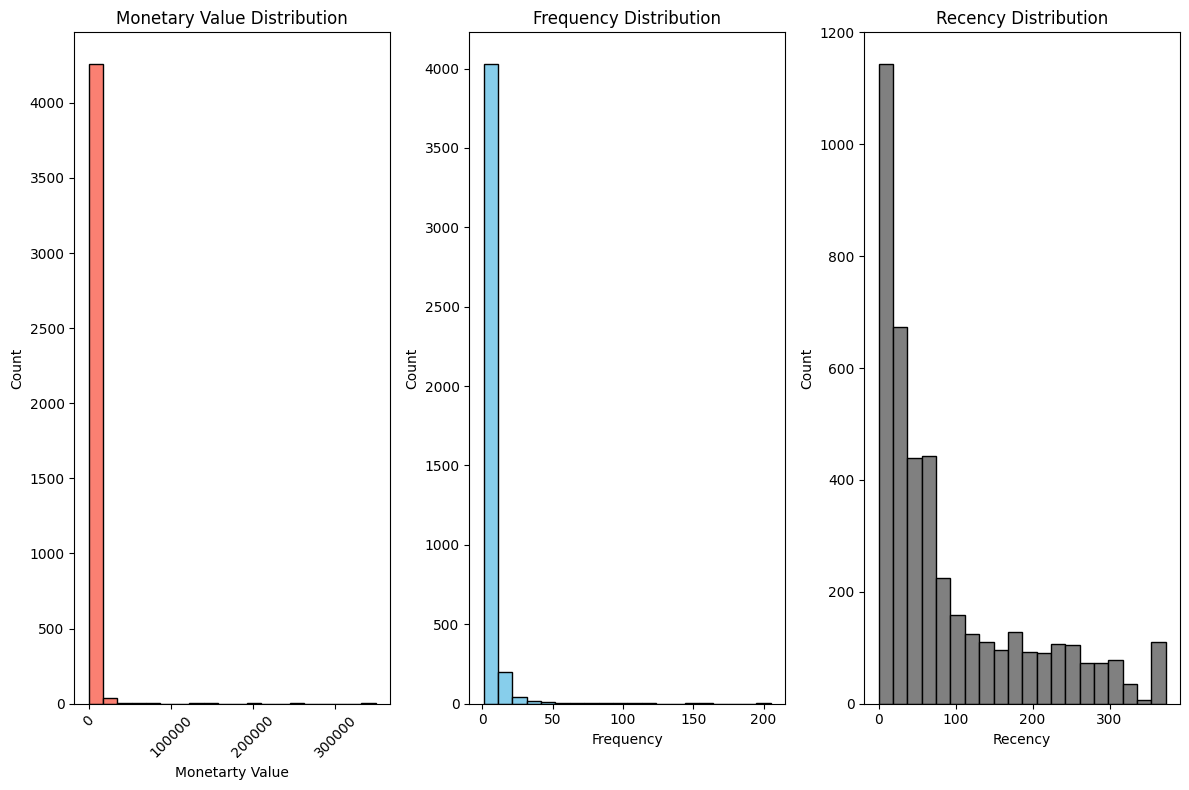

In [30]:
plt.figure(figsize= (12,8))

plt.subplot(1,3,1)

plt.hist(aggregated_df['MonetaryValue'], bins = 20 , color='salmon', edgecolor = 'black')
plt.ylabel('Count')
plt.xlabel('Monetarty Value')
plt.title('Monetary Value Distribution')
plt.xticks(rotation =45)

plt.subplot(1,3,2)

plt.hist(aggregated_df['Frequency'], bins = 20 , color='skyblue', edgecolor = 'black')
plt.ylabel('Count')
plt.xlabel('Frequency')
plt.title('Frequency Distribution')

plt.subplot(1,3,3)

plt.hist(aggregated_df['Recency'], bins = 20, color = 'grey', edgecolor='black')
plt.ylabel('Count')
plt.xlabel('Recency')
plt.title('Recency Distribution')

plt.tight_layout()
plt.show()

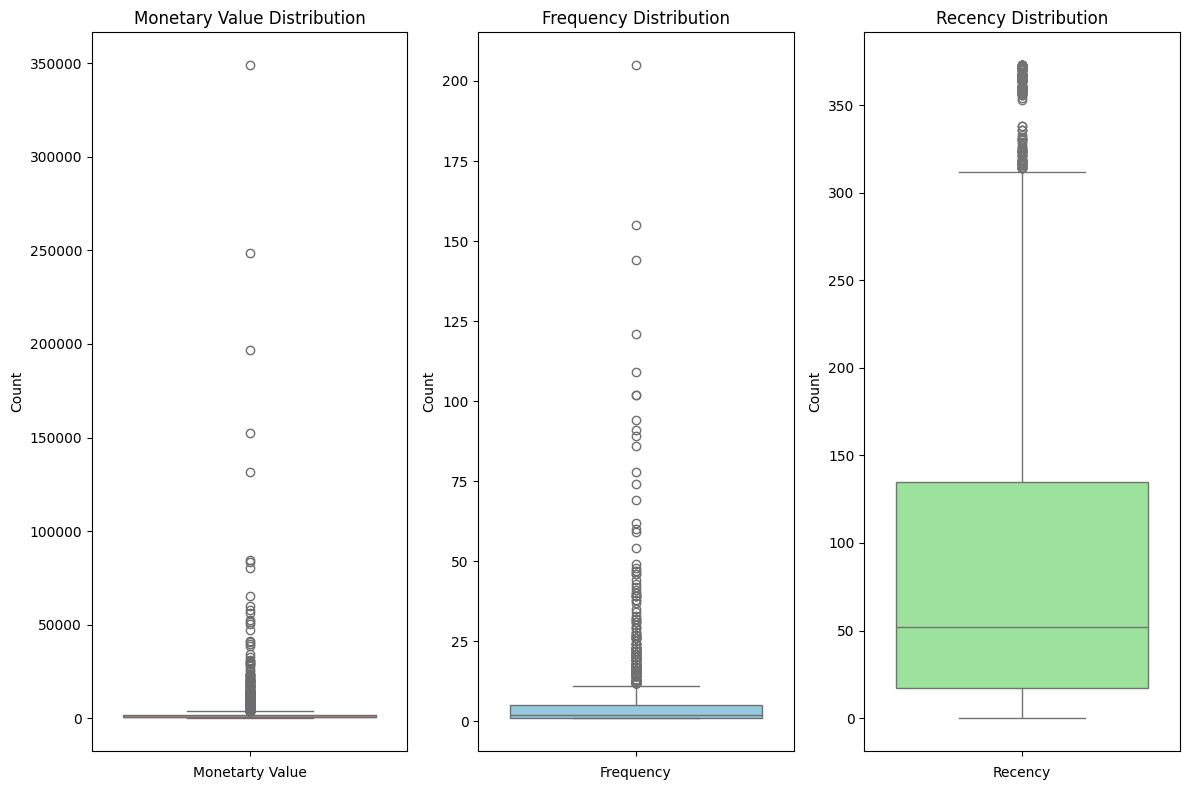

In [31]:
plt.figure(figsize= (12,8))

plt.subplot(1,3,1)

sns.boxplot(data=aggregated_df['MonetaryValue'], color='salmon')
plt.ylabel('Count')
plt.xlabel('Monetarty Value')
plt.title('Monetary Value Distribution')

plt.subplot(1,3,2)

sns.boxplot(data= aggregated_df['Frequency'], color = 'skyblue')
plt.ylabel('Count')
plt.xlabel('Frequency')
plt.title('Frequency Distribution')

plt.subplot(1,3,3)

sns.boxplot(data=aggregated_df['Recency'], color= 'lightgreen')
plt.ylabel('Count')
plt.xlabel('Recency')
plt.title('Recency Distribution')

plt.tight_layout()
plt.show()

In [32]:
outliers_cols = ['MonetaryValue','Frequency']
for i in outliers_cols:
    q1 = np.percentile(aggregated_df[i], 25)
    q3 = np.percentile(aggregated_df[i], 75)
    iqr = q3 - q1
    upper = q3 + 1.5*iqr
    lower = q1 - 1.5*iqr
    filtered = (aggregated_df[i]>= lower) & (aggregated_df[i]<= upper)
    aggregated_df = aggregated_df.loc[filtered]


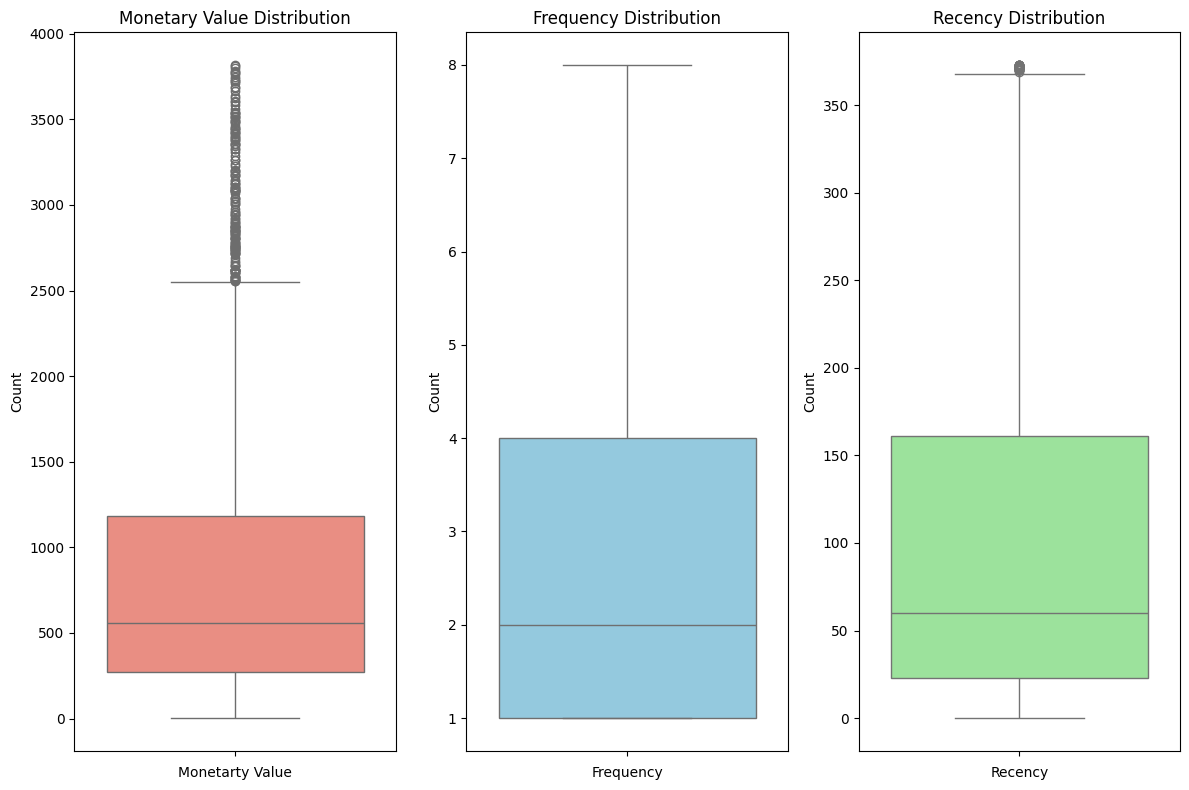

In [33]:
plt.figure(figsize= (12,8))

plt.subplot(1,3,1)

sns.boxplot(data=aggregated_df['MonetaryValue'], color='salmon')
plt.ylabel('Count')
plt.xlabel('Monetarty Value')
plt.title('Monetary Value Distribution')

plt.subplot(1,3,2)

sns.boxplot(data= aggregated_df['Frequency'], color = 'skyblue')
plt.ylabel('Count')
plt.xlabel('Frequency')
plt.title('Frequency Distribution')

plt.subplot(1,3,3)

sns.boxplot(data=aggregated_df['Recency'], color= 'lightgreen')
plt.ylabel('Count')
plt.xlabel('Recency')
plt.title('Recency Distribution')

plt.tight_layout()
plt.show()

Text(0.5, 0, 'Recency')

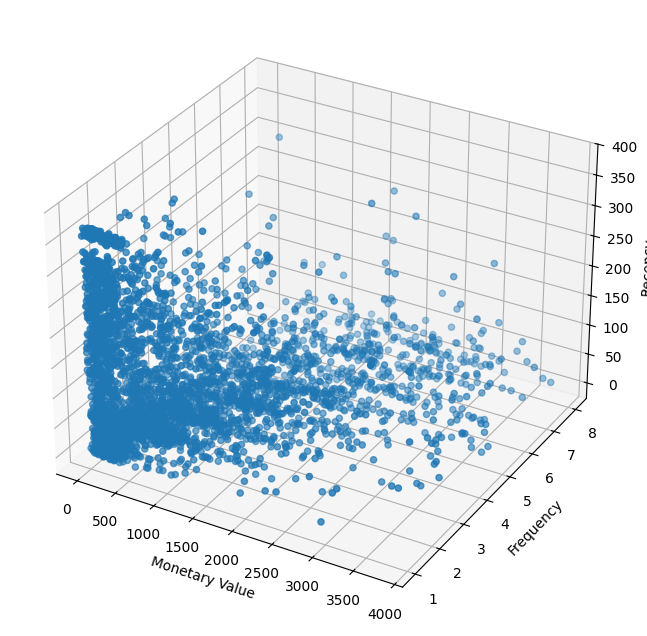

In [34]:
fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(projection='3d')

scatter = ax.scatter(aggregated_df['MonetaryValue'], aggregated_df['Frequency'], aggregated_df['Recency'])

ax.set_xlabel('Monetary Value')
ax.set_ylabel('Frequency')
ax.set_zlabel('Recency')

In [35]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
columns = ['Frequency', 'MonetaryValue', 'Recency']
scaled_data = scaler.fit_transform(aggregated_df[columns])

scaled_df = pd.DataFrame(scaled_data, columns= columns)
scaled_df

,Frequency,MonetaryValue,Recency
0,-0.336039,0.629283,-0.990006
1,-0.870956,-0.793759,-0.275328
2,0.198877,2.371086,-0.587371
3,-0.870956,-0.691964,-0.909479
4,-0.336039,-0.636562,-0.909479
...,...,...,...
3696,1.803627,-0.251492,-0.839018
3697,-0.870956,-0.484225,-0.345789
3698,-0.870956,-0.529042,1.959298
3699,-0.336039,0.594532,0.107175


Text(0.5, 0, 'Recency')

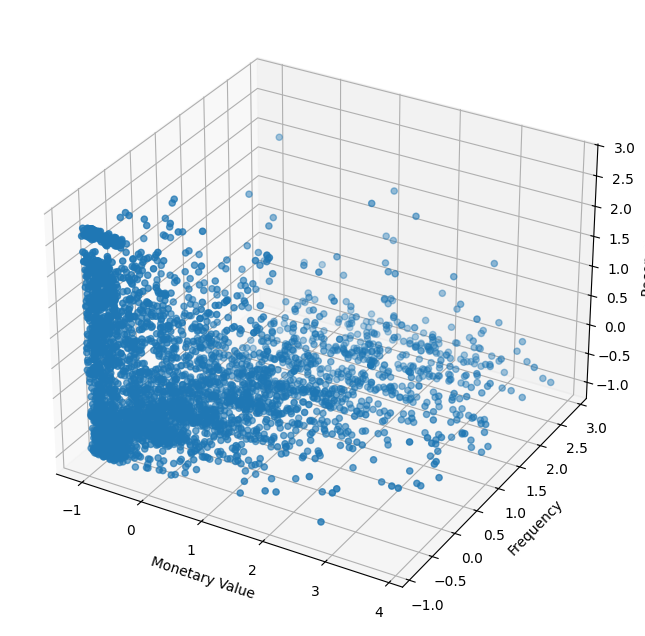

In [36]:
fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(projection='3d')

scatter = ax.scatter(scaled_df['MonetaryValue'], scaled_df['Frequency'], scaled_df['Recency'])

ax.set_xlabel('Monetary Value')
ax.set_ylabel('Frequency')
ax.set_zlabel('Recency')

## KMeans Clustering


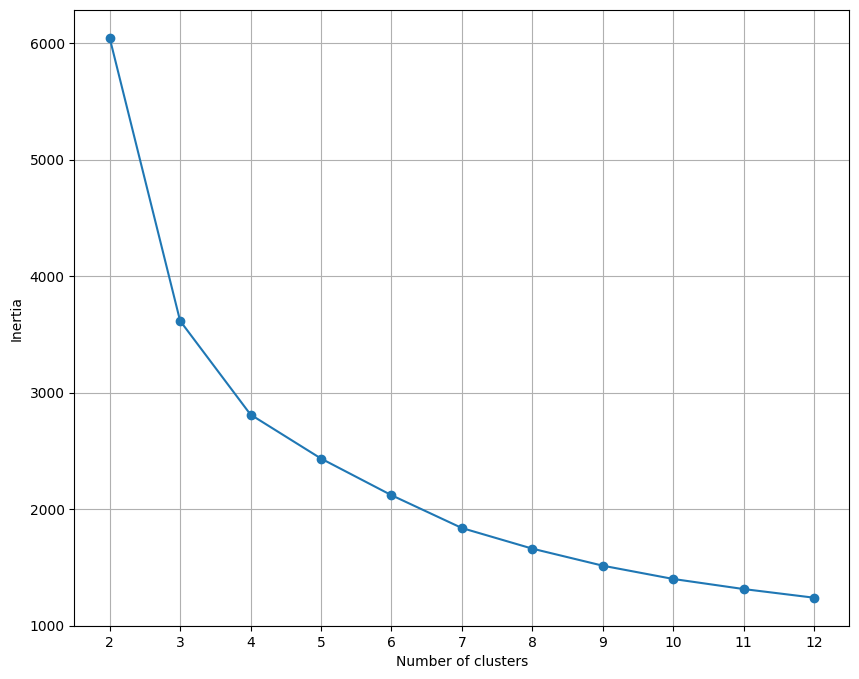

In [37]:
from sklearn.cluster import KMeans

max_k = 12
inertia = []
k_values = range(2, max_k +1)
for k in k_values:
    kmeans = KMeans(init= 'k-means++', n_clusters=k, n_init= 12, max_iter=300, random_state=42)
    kmeans.fit_predict(scaled_df)
    inertia.append(kmeans.inertia_)
plt.figure(figsize= (10,8))
plt.plot(k_values, inertia, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.xticks(k_values)
plt.grid(True)

## Silhouette Score


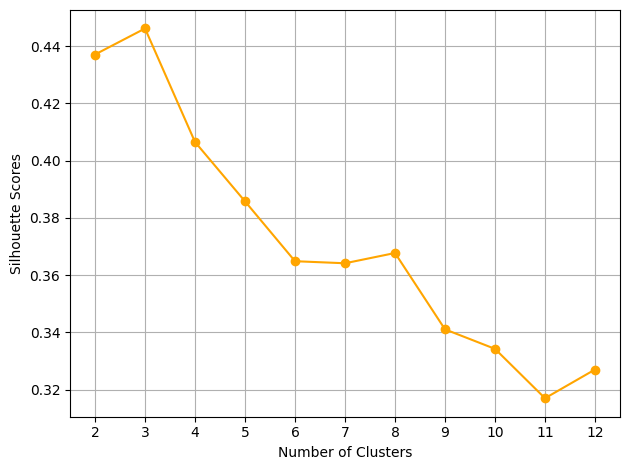

In [38]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans

max_k = 12
silhouette_scores=[]
k_values = range(2, max_k +1)
for k in k_values:
    kmeans = KMeans(init= 'k-means++', n_clusters=k, n_init= 12, max_iter=300, random_state=42)
    cluster_labels = kmeans.fit_predict(scaled_df)
    sil_score = silhouette_score(scaled_df, cluster_labels)
    silhouette_scores.append(sil_score)


plt.plot(k_values, silhouette_scores, marker='o', color='orange')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Scores')
plt.xticks(k_values)
plt.grid(True)

plt.tight_layout()

In [39]:
kmeans = KMeans(n_clusters=4, init='k-means++', n_init= 12, max_iter= 1000, random_state=42)
cluster_labels = kmeans.fit_predict(scaled_data)
cluster_labels

array([1, 0, 3, ..., 2, 1, 3])

In [40]:
aggregated_df['Cluster'] = cluster_labels
aggregated_df

,Customer ID,MonetaryValue,Frequency,LastPurchase,Recency,Cluster
1,12347.0,1323.32,2,2010-12-07 14:57:00,2,1
2,12348.0,222.16,1,2010-09-27 14:59:00,73,0
3,12349.0,2671.14,3,2010-10-28 08:23:00,42,3
4,12351.0,300.93,1,2010-11-29 15:23:00,10,0
5,12352.0,343.80,2,2010-11-29 10:07:00,10,0
...,...,...,...,...,...,...
4307,18283.0,641.77,6,2010-11-22 15:30:00,17,1
4308,18284.0,461.68,1,2010-10-04 11:33:00,66,0
4309,18285.0,427.00,1,2010-02-17 10:24:00,295,2
4310,18286.0,1296.43,2,2010-08-20 11:57:00,111,1


## PCA

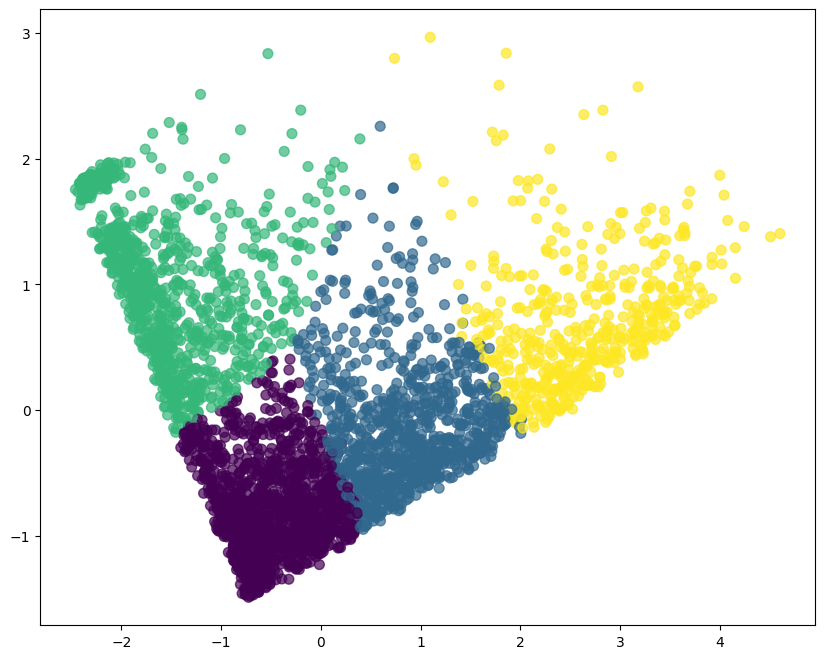

In [41]:
from sklearn.decomposition import PCA

inertia= []
k_max = 12

kmeans= KMeans(n_clusters = 4, init = 'k-means++', n_init = 12,max_iter= 1000, random_state = 42)
labels = kmeans.fit_predict(scaled_df)

pca = PCA(n_components = 2)
reduced_data = pca.fit_transform(scaled_df)


plt.figure(figsize = (10,8))
# plt.scatter(reduced_data[:, 0], reduced_data[:,1], c=labels, cmap='viridis')
plt.scatter(reduced_data[:, 0], reduced_data[:, 1], c=labels, cmap='viridis', s=50, alpha=0.7)
